# 24 — Matching Estimator v2: Causal Renovation Effects on 2026 Data
## RentSignal — Updated CATE with Gemini Image Features as Confounders

**What's new vs v1 (notebook 06):**
| Aspect | v1 (Kaggle 2019) | v2 (Apify 2026) |
|--------|-----------------|-----------------|
| Data | 10,275 listings | ~4,800 regular listings (excluding Tauschwohnungen) |
| Confounders | 11 (structural + categorical) | 30+ (structural + spatial + image) |
| Image controls | None | renovation_level, interior_quality, brightness (from Gemini) |
| Spatial controls | None | dist_cbd_m, count_food_1000m, ndvi_500m, etc. |
| Tauschwohnungen | Mixed in | **Excluded** (different pricing regime, 41% of data) |

**Why exclude Tauschwohnungen?** They are apartment swaps at below-market rent (median €10.37/m² vs €19.00/m²). Including them distorts treatment effect estimates because their pricing is driven by rent control, not amenities.

**Why image confounders matter:** In v1, the balcony effect was negative (-€0.72) — likely because balcony correlates with older, less renovated buildings. With Gemini's `renovation_level` and `interior_quality` as confounders, we can control for visual quality and potentially resolve this puzzle.

In [2]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'

# Load all data tables
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
spatial = pd.read_parquet(PROC_DIR / 'spatial_unit.parquet')
gemini = pd.read_parquet(PROC_DIR / 'gemini_image_features.parquet')

# Merge
df = units.merge(listings[['unit_id', 'rent_sqm', 'baseRent']], on='unit_id')
df = df.merge(spatial.drop(columns=['coord_source']), on='unit_id', how='left')
df = df.merge(gemini[['unit_id', 'interior_quality', 'kitchen_quality', 'bathroom_quality',
                       'brightness', 'renovation_level', 'bldg_condition',
                       'is_render', 'is_furnished', 'has_visible_kitchen', 'has_visible_balcony']],
              on='unit_id', how='left')

# Load raw JSON for NLP features
import re
RAW_FILE = PROJECT_ROOT / 'data' / 'raw' / 'scraping' / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)
raw_lookup = {str(r.get('adTargetingParameters', {}).get('obj_scoutId', '')): r for r in raw}

# Extract is_tauschwohnung
df['is_tauschwohnung'] = df['scout_id'].apply(
    lambda sid: int('tausch' in raw_lookup.get(sid, {}).get('basicInfo', {}).get('title', '').lower())
)

print(f'Total units: {len(df):,}')
print(f'Tauschwohnungen: {df["is_tauschwohnung"].sum():,} ({100*df["is_tauschwohnung"].mean():.1f}%)')
print(f'Regular listings: {(~df["is_tauschwohnung"].astype(bool)).sum():,}')

# EXCLUDE Tauschwohnungen
df_reg = df[df['is_tauschwohnung'] == 0].copy().reset_index(drop=True)
print(f'\nWorking dataset (regular only): {len(df_reg):,} listings')
print(f'Mean rent: €{df_reg["rent_sqm"].mean():.2f}/m²')

# Define outcome and treatments
OUTCOME = 'rent_sqm'
TREATMENTS = ['hasKitchen', 'balcony', 'lift', 'garden']

# Ensure binary
for t in TREATMENTS:
    df_reg[t] = df_reg[t].astype(int)

print(f'\nTreatment prevalence (regular listings):')
for t in TREATMENTS:
    n_t = df_reg[t].sum()
    print(f'  {t}: {n_t:,} treated ({100*n_t/len(df_reg):.1f}%), {len(df_reg)-n_t:,} control')

Total units: 8,256
Tauschwohnungen: 3,428 (41.5%)
Regular listings: 4,828

Working dataset (regular only): 4,828 listings
Mean rent: €19.57/m²

Treatment prevalence (regular listings):
  hasKitchen: 2,597 treated (53.8%), 2,231 control
  balcony: 2,532 treated (52.4%), 2,296 control
  lift: 2,025 treated (41.9%), 2,803 control
  garden: 636 treated (13.2%), 4,192 control


## Define Confounders (v2: expanded with spatial + image)

In [3]:
# v2 Confounders — much richer than v1
CONTINUOUS_CONFOUNDERS = [
    # Structural
    'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 'thermalChar', 'sqm_per_room',
    # Spatial (key location features)
    'dist_cbd_m', 'dist_transit_m', 'dist_ubahn_m', 'dist_park_m', 'dist_water_m',
    'count_food_1000m', 'count_restaurant_1000m', 'count_cafe_500m', 'count_shop_1000m',
    # Satellite
    'ndvi_500m', 'ndwi_500m', 'ndbi_500m',
    # Gemini image (CRITICAL — controls for visual quality)
    'interior_quality', 'renovation_level', 'brightness', 'bldg_condition',
]

CATEGORICAL_CONFOUNDERS = [
    'building_era', 'bezirk', 'condition', 'interiorQual',
]

# Fill missing values for matching
for col in CONTINUOUS_CONFOUNDERS:
    df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce')
    if df_reg[col].isna().sum() > 0:
        df_reg[col] = df_reg[col].fillna(df_reg[col].median())

for col in CATEGORICAL_CONFOUNDERS:
    df_reg[col] = df_reg[col].fillna('unknown').astype(str)

print(f'Confounders: {len(CONTINUOUS_CONFOUNDERS)} continuous + {len(CATEGORICAL_CONFOUNDERS)} categorical')
print(f'  = {len(CONTINUOUS_CONFOUNDERS) + len(CATEGORICAL_CONFOUNDERS)} total (v1 had 11)')
print(f'\nNew confounders not in v1:')
v1_confounders = {'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 
                  'thermalChar', 'sqm_per_room', 'building_era', 'bezirk', 'condition', 'interiorQual'}
new_confounders = [c for c in CONTINUOUS_CONFOUNDERS + CATEGORICAL_CONFOUNDERS if c not in v1_confounders]
for c in new_confounders:
    print(f'  + {c}')

Confounders: 23 continuous + 4 categorical
  = 27 total (v1 had 11)

New confounders not in v1:
  + dist_cbd_m
  + dist_transit_m
  + dist_ubahn_m
  + dist_park_m
  + dist_water_m
  + count_food_1000m
  + count_restaurant_1000m
  + count_cafe_500m
  + count_shop_1000m
  + ndvi_500m
  + ndwi_500m
  + ndbi_500m
  + interior_quality
  + renovation_level
  + brightness
  + bldg_condition


## PSM Helper Functions (same as v1, proven pipeline)

In [4]:
# PSM functions — same proven pipeline from v1

def prepare_confounders(df, treatment_col, continuous_cols, categorical_cols, other_treatments):
    X_parts, col_names = [], []
    X_cont = df[continuous_cols].values.astype(float)
    scaler = StandardScaler()
    X_cont = scaler.fit_transform(X_cont)
    X_parts.append(X_cont)
    col_names.extend(continuous_cols)
    
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_cat = enc.fit_transform(df[categorical_cols])
    X_parts.append(X_cat)
    col_names.extend(categorical_cols)
    
    other_tx = [t for t in other_treatments if t != treatment_col]
    if other_tx:
        X_parts.append(df[other_tx].values.astype(float))
        col_names.extend(other_tx)
    
    return np.hstack(X_parts), col_names


def estimate_propensity_score(df, treatment_col, X):
    y = df[treatment_col].values.astype(int)
    lr = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
    lr.fit(X, y)
    ps = lr.predict_proba(X)[:, 1]
    eps = 1e-6
    ps_clipped = np.clip(ps, eps, 1 - eps)
    logit_ps = np.log(ps_clipped / (1 - ps_clipped))
    return ps, logit_ps


def match_nearest_neighbor(df, treatment_col, logit_ps, caliper_sd=0.2):
    treated_mask = df[treatment_col].values.astype(bool)
    treated_idx = np.where(treated_mask)[0]
    control_idx = np.where(~treated_mask)[0]
    caliper = caliper_sd * logit_ps.std()
    
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(logit_ps[control_idx].reshape(-1, 1))
    distances, indices = nn.kneighbors(logit_ps[treated_idx].reshape(-1, 1))
    distances, indices = distances.flatten(), indices.flatten()
    
    matches, used = [], set()
    for i in np.argsort(distances):
        if distances[i] > caliper:
            continue
        ctrl = control_idx[indices[i]]
        if ctrl in used:
            continue
        used.add(ctrl)
        matches.append({'treated_idx': treated_idx[i], 'control_idx': ctrl, 'distance': distances[i]})
    
    return pd.DataFrame(matches)


def compute_smd(t_vals, c_vals):
    pooled = np.sqrt((t_vals.std()**2 + c_vals.std()**2) / 2)
    return abs(t_vals.mean() - c_vals.mean()) / pooled if pooled > 0 else 0.0


def check_balance(df, match_df, treatment_col, confounder_cols):
    treated_mask = df[treatment_col].values.astype(bool)
    results = []
    for col in confounder_cols:
        vals = pd.to_numeric(df[col], errors='coerce')
        if vals.isna().all():
            vals = df[col].astype('category').cat.codes.astype(float)
        smd_before = compute_smd(vals[treated_mask], vals[~treated_mask])
        mt = vals.iloc[match_df['treated_idx'].values]
        mc = vals.iloc[match_df['control_idx'].values]
        smd_after = compute_smd(mt.values, mc.values)
        results.append({'Confounder': col, 'SMD_before': round(smd_before, 3),
                       'SMD_after': round(smd_after, 3), 'Balanced': smd_after < 0.1})
    return pd.DataFrame(results)


def estimate_att(df, match_df, outcome_col, n_bootstrap=1000, seed=42):
    y = df[outcome_col].values
    diffs = y[match_df['treated_idx'].values] - y[match_df['control_idx'].values]
    att = diffs.mean()
    rng = np.random.RandomState(seed)
    boot = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_bootstrap)]
    boot = np.array(boot)
    return {'att': round(att, 3), 'se': round(boot.std(), 3),
            'ci_low': round(np.percentile(boot, 2.5), 3),
            'ci_high': round(np.percentile(boot, 97.5), 3), 'n_pairs': len(diffs)}


def run_full_pipeline(df, treatment_col, outcome_col='rent_sqm', caliper_sd=0.2,
                      n_bootstrap=1000, verbose=True):
    if verbose:
        n_t = df[treatment_col].sum()
        print(f'\n{"="*60}')
        print(f'Treatment: {treatment_col}  |  Treated: {n_t:,}  |  Control: {len(df)-n_t:,}')
        print(f'{"="*60}')
    
    X, col_names = prepare_confounders(df, treatment_col, CONTINUOUS_CONFOUNDERS, CATEGORICAL_CONFOUNDERS, TREATMENTS)
    ps, logit_ps = estimate_propensity_score(df, treatment_col, X)
    match_df = match_nearest_neighbor(df, treatment_col, logit_ps, caliper_sd)
    
    if verbose:
        print(f'Matched: {len(match_df):,} pairs ({100*len(match_df)/df[treatment_col].sum():.1f}% match rate)')
    
    all_confounders = CONTINUOUS_CONFOUNDERS + CATEGORICAL_CONFOUNDERS + [t for t in TREATMENTS if t != treatment_col]
    balance = check_balance(df, match_df, treatment_col, all_confounders)
    n_bal = balance['Balanced'].sum()
    
    if verbose:
        print(f'Balance: {n_bal}/{len(balance)} confounders with SMD < 0.1')
    
    att = estimate_att(df, match_df, outcome_col, n_bootstrap)
    att['treatment'] = treatment_col
    
    if verbose:
        print(f'ATT: {att["att"]:+.2f} €/m²  [{att["ci_low"]:.2f}, {att["ci_high"]:.2f}]')
    
    return att, match_df, balance, ps

print('PSM functions defined.')

PSM functions defined.


## Run All 4 Treatments

In [5]:
# Run PSM for all 4 treatments on 2026 regular listings
all_results_v2 = []
all_balances = {}

for treatment in TREATMENTS:
    result, match_df, balance, ps = run_full_pipeline(
        df_reg, treatment, caliper_sd=0.2, n_bootstrap=1000, verbose=True
    )
    all_results_v2.append(result)
    all_balances[treatment] = balance

results_v2 = pd.DataFrame(all_results_v2)

# Load v1 results for comparison
v1_path = PROC_DIR / 'matching_results.json'
if v1_path.exists():
    with open(v1_path) as f:
        v1_data = json.load(f)
    v1_results = v1_data['results']
else:
    v1_results = {}

# Comparison table
print(f'\n{"="*75}')
print(f'  v1 (Kaggle 2019) vs v2 (Apify 2026, excl. Tauschwohnungen)')
print(f'{"="*75}')
print(f'  {"Treatment":<12} {"v1 CATE":>10} {"v1 CI":>18} {"v2 CATE":>10} {"v2 CI":>18} {"Δ":>8}')
print(f'  {"-"*72}')
for _, row in results_v2.iterrows():
    t = row['treatment']
    v1 = v1_results.get(t, {})
    v1_att = v1.get('att', 'N/A')
    v1_ci = f'[{v1.get("ci_low","?")}, {v1.get("ci_high","?")}]' if v1 else 'N/A'
    v2_att = row['att']
    v2_ci = f'[{row["ci_low"]}, {row["ci_high"]}]'
    delta = f'{v2_att - v1_att:+.2f}' if isinstance(v1_att, (int, float)) else 'N/A'
    v1_str = f'{v1_att:+.2f}' if isinstance(v1_att, (int, float)) else 'N/A'
    print(f'  {t:<12} {v1_str:>10} {v1_ci:>18} {v2_att:>+10.2f} {v2_ci:>18} {delta:>8}')


Treatment: hasKitchen  |  Treated: 2,597  |  Control: 2,231
Matched: 714 pairs (27.5% match rate)
Balance: 28/30 confounders with SMD < 0.1
ATT: +3.48 €/m²  [2.81, 4.20]

Treatment: balcony  |  Treated: 2,532  |  Control: 2,296
Matched: 657 pairs (25.9% match rate)
Balance: 30/30 confounders with SMD < 0.1
ATT: +1.08 €/m²  [0.21, 1.97]

Treatment: lift  |  Treated: 2,025  |  Control: 2,803
Matched: 578 pairs (28.5% match rate)
Balance: 24/30 confounders with SMD < 0.1
ATT: +1.59 €/m²  [0.75, 2.48]

Treatment: garden  |  Treated: 636  |  Control: 4,192
Matched: 480 pairs (75.5% match rate)
Balance: 30/30 confounders with SMD < 0.1
ATT: +1.36 €/m²  [0.53, 2.17]

  v1 (Kaggle 2019) vs v2 (Apify 2026, excl. Tauschwohnungen)
  Treatment       v1 CATE              v1 CI    v2 CATE              v2 CI        Δ
  ------------------------------------------------------------------------
  hasKitchen        +2.91     [2.647, 3.184]      +3.48     [2.806, 4.198]    +0.57
  balcony           -0.72 

## Visualization + Convergence with Conjoint WTP

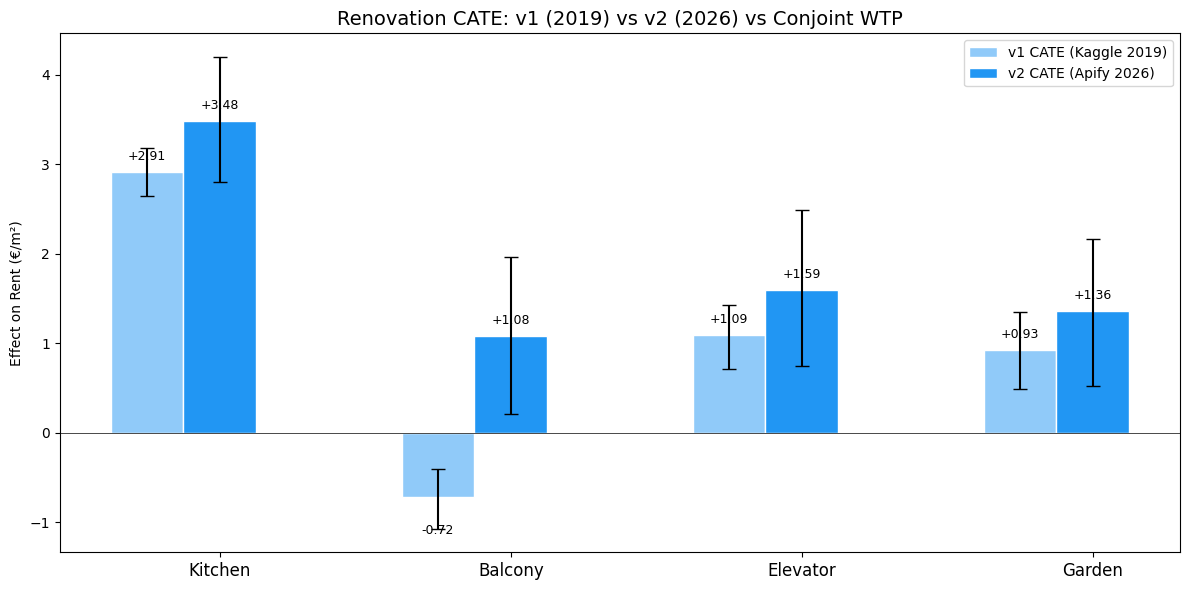


=== Convergence Analysis ===

  Kitchen:
    v1 CATE (2019):     +2.91 €/m²
    v2 CATE (2026):     +3.48 €/m²

  Balcony:
    v1 CATE (2019):     -0.72 €/m²
    v2 CATE (2026):     +1.08 €/m²

  Elevator:
    v1 CATE (2019):     +1.09 €/m²
    v2 CATE (2026):     +1.59 €/m²

  Garden:
    v1 CATE (2019):     +0.93 €/m²
    v2 CATE (2026):     +1.36 €/m²


In [6]:
# Load conjoint WTP results
conjoint_path = PROC_DIR / 'conjoint_results.json'
if conjoint_path.exists():
    with open(conjoint_path) as f:
        conjoint_data = json.load(f)
    conjoint_wtp = conjoint_data.get('wtp', conjoint_data.get('results', {}))
else:
    conjoint_wtp = {}

# Build comparison: v1 CATE vs v2 CATE vs Conjoint WTP
fig, ax = plt.subplots(figsize=(12, 6))

labels = ['Kitchen', 'Balcony', 'Elevator', 'Garden']
treatment_keys = ['hasKitchen', 'balcony', 'lift', 'garden']
conjoint_keys = ['hasKitchen', 'balcony', 'lift', 'garden']  # adjust if conjoint uses different keys

x = np.arange(len(labels))
width = 0.25

# v1 CATE (Kaggle 2019)
v1_vals = [v1_results.get(t, {}).get('att', 0) for t in treatment_keys]
v1_lo = [v1_results.get(t, {}).get('ci_low', 0) for t in treatment_keys]
v1_hi = [v1_results.get(t, {}).get('ci_high', 0) for t in treatment_keys]
v1_err = [[v - l for v, l in zip(v1_vals, v1_lo)], [h - v for v, h in zip(v1_vals, v1_hi)]]

# v2 CATE (Apify 2026)
v2_vals = [results_v2[results_v2['treatment'] == t]['att'].values[0] for t in treatment_keys]
v2_lo = [results_v2[results_v2['treatment'] == t]['ci_low'].values[0] for t in treatment_keys]
v2_hi = [results_v2[results_v2['treatment'] == t]['ci_high'].values[0] for t in treatment_keys]
v2_err = [[v - l for v, l in zip(v2_vals, v2_lo)], [h - v for v, h in zip(v2_vals, v2_hi)]]

# Conjoint WTP
wtp_vals = []
for t in conjoint_keys:
    wtp = conjoint_wtp.get(t, {})
    if isinstance(wtp, dict):
        wtp_vals.append(wtp.get('wtp_sqm', wtp.get('att', 0)))
    elif isinstance(wtp, (int, float)):
        wtp_vals.append(wtp)
    else:
        wtp_vals.append(0)

bars1 = ax.bar(x - width, v1_vals, width, label='v1 CATE (Kaggle 2019)', color='#90CAF9', 
               yerr=v1_err, capsize=5, edgecolor='white')
bars2 = ax.bar(x, v2_vals, width, label='v2 CATE (Apify 2026)', color='#2196F3',
               yerr=v2_err, capsize=5, edgecolor='white')
if any(v != 0 for v in wtp_vals):
    bars3 = ax.bar(x + width, wtp_vals, width, label='Conjoint WTP', color='#FF9800',
                   edgecolor='white')

ax.set_ylabel('Effect on Rent (€/m²)')
ax.set_title('Renovation CATE: v1 (2019) vs v2 (2026) vs Conjoint WTP', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=10)

# Value labels
for bars, vals in [(bars1, v1_vals), (bars2, v2_vals)]:
    for bar, val in zip(bars, vals):
        y = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, y + (0.1 if y >= 0 else -0.3),
                f'{val:+.2f}', ha='center', va='bottom' if y >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

# Print convergence analysis
print('\n=== Convergence Analysis ===')
for i, (label, t) in enumerate(zip(labels, treatment_keys)):
    v2 = v2_vals[i]
    wtp = wtp_vals[i] if wtp_vals[i] != 0 else None
    v1 = v1_vals[i]
    print(f'\n  {label}:')
    print(f'    v1 CATE (2019):     {v1:+.2f} €/m²')
    print(f'    v2 CATE (2026):     {v2:+.2f} €/m²')
    if wtp is not None:
        print(f'    Conjoint WTP:       {wtp:+.2f} €/m²')
        diff_pct = abs(v2 - wtp) / max(abs(v2), abs(wtp), 0.01) * 100
        converge = '✓ CONVERGE' if diff_pct < 30 else '✗ DIVERGE'
        print(f'    v2↔WTP gap:         {abs(v2-wtp):.2f} €/m² ({diff_pct:.0f}%) {converge}')

## Heterogeneous Kitchen CATE by Building Era

  unknown: CATE = +4.07 €/m² [2.39, 5.68] (165 pairs)
  2015_plus: CATE = +0.91 €/m² [-0.42, 2.18] (183 pairs)
  pre_1918: CATE = +1.35 €/m² [-0.27, 2.88] (117 pairs)
  1991_2002: CATE = -0.93 €/m² [-3.23, 1.64] (37 pairs)
  1973_1990: CATE = +2.15 €/m² [-1.60, 5.91] (14 pairs)
  1950_1964: CATE = +4.22 €/m² [-0.09, 9.64] (14 pairs)
  1919_1949: CATE = -2.25 €/m² [-7.30, 2.20] (11 pairs)
  Skipping 2003_2014: 82 treated, 8 control
  1965_1972: CATE = +6.00 €/m² [1.51, 10.53] (8 pairs)


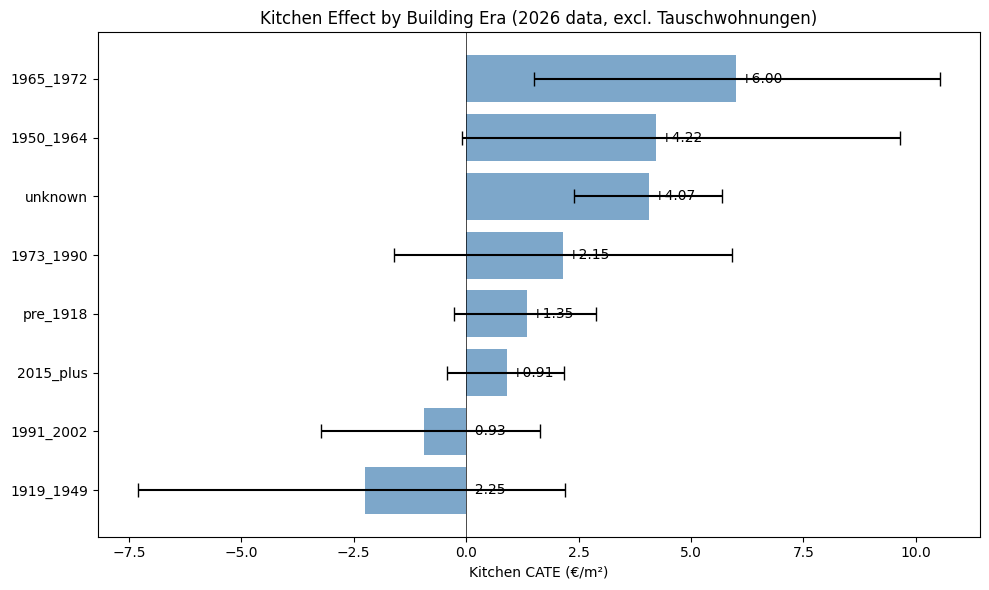

In [7]:
# Heterogeneous kitchen effects by building era
era_results_v2 = []

for era in df_reg['building_era'].value_counts().index:
    sub = df_reg[df_reg['building_era'] == era].copy().reset_index(drop=True)
    n_t = sub['hasKitchen'].sum()
    n_c = len(sub) - n_t
    if n_t < 30 or n_c < 30:
        print(f'  Skipping {era}: {n_t} treated, {n_c} control')
        continue
    try:
        result, _, _, _ = run_full_pipeline(sub, 'hasKitchen', caliper_sd=0.3,
                                           n_bootstrap=500, verbose=False)
        result['era'] = era
        era_results_v2.append(result)
        print(f'  {era}: CATE = {result["att"]:+.2f} €/m² [{result["ci_low"]:.2f}, {result["ci_high"]:.2f}] ({result["n_pairs"]} pairs)')
    except Exception as e:
        print(f'  {era}: FAILED ({e})')

if era_results_v2:
    era_df_v2 = pd.DataFrame(era_results_v2).sort_values('att')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    y = range(len(era_df_v2))
    ax.barh(y, era_df_v2['att'],
            xerr=[era_df_v2['att']-era_df_v2['ci_low'], era_df_v2['ci_high']-era_df_v2['att']],
            color='steelblue', alpha=0.7, capsize=5)
    ax.set_yticks(list(y))
    ax.set_yticklabels(era_df_v2['era'])
    ax.set_xlabel('Kitchen CATE (€/m²)')
    ax.set_title('Kitchen Effect by Building Era (2026 data, excl. Tauschwohnungen)')
    ax.axvline(0, color='black', linewidth=0.5)
    for i, row in enumerate(era_df_v2.itertuples()):
        ax.text(max(row.att, 0) + 0.1, i, f'{row.att:+.2f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

## Save v2 Results

In [11]:
# Save v2 matching results
export_v2 = {
    'method': 'Propensity Score Matching (1:1 NN, caliper=0.2 SD)',
    'version': 'v2',
    'dataset': 'Apify ImmoScout24 Berlin 2026 (regular listings only, excl. Tauschwohnungen)',
    'n_listings': len(df_reg),
    'confounders': CONTINUOUS_CONFOUNDERS + CATEGORICAL_CONFOUNDERS,
    'n_confounders': len(CONTINUOUS_CONFOUNDERS) + len(CATEGORICAL_CONFOUNDERS),
    'improvements_over_v1': [
        '2026 data (vs 2019)',
        'Tauschwohnungen excluded (41% of listings with non-market pricing)',
        f'{len(CONTINUOUS_CONFOUNDERS)+len(CATEGORICAL_CONFOUNDERS)} confounders (vs 11 in v1)',
        'Gemini image features as confounders (renovation_level, interior_quality, brightness)',
        'Unit-level spatial features as confounders (dist_cbd, food density, NDVI)',
    ],
    'results': {},
}

for r in all_results_v2:
    t = r['treatment']
    raw = df_reg[df_reg[t].astype(bool)]['rent_sqm'].mean() - df_reg[~df_reg[t].astype(bool)]['rent_sqm'].mean()
    export_v2['results'][t] = {
        'att': r['att'],
        'ci_low': r['ci_low'],
        'ci_high': r['ci_high'],
        'se': r['se'],
        'n_pairs': r['n_pairs'],
        'raw_premium': round(raw, 3),
    }

# Add heterogeneous kitchen effects
if era_results_v2:
    export_v2['heterogeneous_kitchen'] = {
        r['era']: {'att': r['att'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'], 'n_pairs': r['n_pairs']}
        for r in era_results_v2
    }

# Save
output_path = PROC_DIR / 'matching_results_v2.json'
with open(output_path, 'w') as f:
    json.dump(export_v2, f, indent=2)

print(f'Saved: {output_path.name}')
print(f'\n=== v2 Summary ===')
print(f'  Data: {len(df_reg):,} regular listings (2026)')
print(f'  Confounders: {export_v2["n_confounders"]} (including Gemini image + spatial)')
for t, res in export_v2['results'].items():
    print(f'  {t}: CATE = {res["att"]:+.2f} €/m² [{res["ci_low"]:.2f}, {res["ci_high"]:.2f}] ({res["n_pairs"]} pairs)')

Saved: matching_results_v2.json

=== v2 Summary ===
  Data: 4,828 regular listings (2026)
  Confounders: 27 (including Gemini image + spatial)
  hasKitchen: CATE = +3.48 €/m² [2.81, 4.20] (714 pairs)
  balcony: CATE = +1.08 €/m² [0.21, 1.97] (657 pairs)
  lift: CATE = +1.59 €/m² [0.75, 2.48] (578 pairs)
  garden: CATE = +1.36 €/m² [0.53, 2.17] (480 pairs)


## Extended Treatments: Gemini-Based + Structural

5 additional treatments beyond the classic 4. These use AI-extracted image features as treatment indicators — novel in the hedonic pricing literature.

| Treatment | Type | Definition |
|-----------|------|-----------|
| cellar | Renovation | `cellar == 1` (storage access) |
| dielen_floor | Renovation | `floor_type == 'dielen'` vs other (from Gemini) |
| high_ceiling | Feature premium | `ceiling_height == 'high'` (from Gemini) |
| visually_renovated | Renovation | `renovation_level >= 4` vs `<= 2` (from Gemini) |
| energy_efficient | Renovation | `thermalChar < 100` vs `> 150` (kWh/m²) |

In [9]:
# Create binary treatment variables for the 5 new treatments

# 1. Cellar (already binary)
df_reg['tx_cellar'] = df_reg['cellar'].astype(int)

# 2. Dielen floor (from Gemini — need to merge floor_type)
gemini_floor = gemini[['unit_id', 'floor_type']].copy()
df_reg = df_reg.merge(gemini_floor, on='unit_id', how='left')
df_reg['floor_type'] = df_reg['floor_type'].fillna('unknown')
df_reg['tx_dielen'] = (df_reg['floor_type'] == 'dielen').astype(int)

# 3. High ceiling (from Gemini)
gemini_ceil = gemini[['unit_id', 'ceiling_height']].copy()
df_reg = df_reg.merge(gemini_ceil, on='unit_id', how='left')
df_reg['ceiling_height'] = df_reg['ceiling_height'].fillna('normal')
df_reg['tx_high_ceiling'] = (df_reg['ceiling_height'] == 'high').astype(int)

# 4. Visually renovated (renovation_level >= 4 vs <= 2, drop 3 = ambiguous middle)
df_reg['tx_visually_renovated'] = 0
df_reg.loc[df_reg['renovation_level'] >= 4, 'tx_visually_renovated'] = 1
# Control group: renovation_level <= 2
# We need to EXCLUDE the middle (3) from this specific matching to get clean comparison
df_renovated = df_reg[df_reg['renovation_level'].isin([1, 2, 4, 5]) | df_reg['renovation_level'].isna()].copy().reset_index(drop=True)
df_renovated['tx_visually_renovated'] = (df_renovated['renovation_level'] >= 4).astype(int)

# 5. Energy efficient (thermalChar < 100 vs > 150)
df_energy = df_reg[(df_reg['thermalChar'] < 100) | (df_reg['thermalChar'] > 150)].copy().reset_index(drop=True)
df_energy['tx_energy_efficient'] = (df_energy['thermalChar'] < 100).astype(int)

# Treatment prevalence
extended_treatments = [
    ('tx_cellar', df_reg, 'Cellar'),
    ('tx_dielen', df_reg, 'Dielen Floor'),
    ('tx_high_ceiling', df_reg, 'High Ceiling'),
    ('tx_visually_renovated', df_renovated, 'Visually Renovated'),
    ('tx_energy_efficient', df_energy, 'Energy Efficient'),
]

print('Extended treatment prevalence:')
for tx_col, tx_df, label in extended_treatments:
    n_t = tx_df[tx_col].sum()
    n_c = len(tx_df) - n_t
    print(f'  {label:<25} treated={n_t:>5,}  control={n_c:>5,}  ({100*n_t/len(tx_df):.1f}%)')

Extended treatment prevalence:
  Cellar                    treated=1,824  control=3,004  (37.8%)
  Dielen Floor              treated=  351  control=4,477  (7.3%)
  High Ceiling              treated=  252  control=4,576  (5.2%)
  Visually Renovated        treated=3,382  control=  186  (94.8%)
  Energy Efficient          treated=4,302  control=  154  (96.5%)


In [10]:
# Run PSM for all 5 extended treatments
# Need to adjust TREATMENTS list temporarily for each run (other treatments as confounders)

extended_results = []

for tx_col, tx_df, label in extended_treatments:
    n_t = tx_df[tx_col].sum()
    n_c = len(tx_df) - n_t
    if n_t < 30 or n_c < 30:
        print(f'  Skipping {label}: {n_t} treated, {n_c} control (too few)')
        continue
    
    # Save original TREATMENTS, temporarily set for this run
    orig_treatments = TREATMENTS
    # Include the classic 4 treatments as confounders (but not the current treatment)
    TREATMENTS = ['hasKitchen', 'balcony', 'lift', 'garden', tx_col]
    
    try:
        result, match_df, balance, ps = run_full_pipeline(
            tx_df, tx_col, caliper_sd=0.25, n_bootstrap=1000, verbose=True
        )
        result['label'] = label
        extended_results.append(result)
    except Exception as e:
        print(f'  {label}: FAILED ({e})')
    
    TREATMENTS = orig_treatments

# Summary
if extended_results:
    ext_df = pd.DataFrame(extended_results)
    print(f'\n{"="*70}')
    print(f'  EXTENDED TREATMENT EFFECTS (Gemini-based + Structural)')
    print(f'{"="*70}')
    for _, row in ext_df.iterrows():
        print(f'  {row["label"]:<25} CATE = {row["att"]:+.2f} €/m²  [{row["ci_low"]:.2f}, {row["ci_high"]:.2f}]  ({row["n_pairs"]} pairs)')


Treatment: tx_cellar  |  Treated: 1,824  |  Control: 3,004
Matched: 812 pairs (44.5% match rate)
Balance: 30/31 confounders with SMD < 0.1
ATT: -0.90 €/m²  [-1.56, -0.22]

Treatment: tx_dielen  |  Treated: 351  |  Control: 4,477
Matched: 271 pairs (77.2% match rate)
Balance: 29/31 confounders with SMD < 0.1
ATT: +1.28 €/m²  [0.17, 2.33]

Treatment: tx_high_ceiling  |  Treated: 252  |  Control: 4,576
Matched: 215 pairs (85.3% match rate)
Balance: 25/31 confounders with SMD < 0.1
ATT: +1.97 €/m²  [0.59, 3.28]

Treatment: tx_visually_renovated  |  Treated: 3,382  |  Control: 186
Matched: 0 pairs (0.0% match rate)
  Visually Renovated: FAILED ('treated_idx')

Treatment: tx_energy_efficient  |  Treated: 4,302  |  Control: 154
Matched: 0 pairs (0.0% match rate)
  Energy Efficient: FAILED ('treated_idx')

  EXTENDED TREATMENT EFFECTS (Gemini-based + Structural)
  Cellar                    CATE = -0.90 €/m²  [-1.56, -0.22]  (812 pairs)
  Dielen Floor              CATE = +1.28 €/m²  [0.17, 2.3

In [12]:
# Save all v2 results (classic 4 + extended)
export_v2 = {
    'method': 'Propensity Score Matching (1:1 NN, caliper=0.2-0.25 SD)',
    'version': 'v2',
    'dataset': 'Apify ImmoScout24 Berlin 2026 (regular listings only, excl. Tauschwohnungen)',
    'n_listings': len(df_reg),
    'confounders': CONTINUOUS_CONFOUNDERS + CATEGORICAL_CONFOUNDERS,
    'n_confounders': len(CONTINUOUS_CONFOUNDERS) + len(CATEGORICAL_CONFOUNDERS),
    'improvements_over_v1': [
        '2026 data (vs 2019)',
        'Tauschwohnungen excluded (41% of listings with non-market pricing)',
        f'{len(CONTINUOUS_CONFOUNDERS)+len(CATEGORICAL_CONFOUNDERS)} confounders (vs 11 in v1)',
        'Gemini image features as confounders (renovation_level, interior_quality, brightness)',
        'Unit-level spatial features as confounders (dist_cbd, food density, NDVI)',
    ],
    'classic_treatments': {},
    'extended_treatments': {},
}

# Classic 4
for r in all_results_v2:
    t = r['treatment']
    raw = df_reg[df_reg[t].astype(bool)]['rent_sqm'].mean() - df_reg[~df_reg[t].astype(bool)]['rent_sqm'].mean()
    export_v2['classic_treatments'][t] = {
        'att': r['att'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'],
        'se': r['se'], 'n_pairs': r['n_pairs'], 'raw_premium': round(raw, 3),
        'type': 'renovation',
    }

# Extended
for r in extended_results:
    tx = r['treatment']
    label = r.get('label', tx)
    tx_type = 'feature_premium' if 'ceiling' in tx else 'renovation'
    export_v2['extended_treatments'][tx] = {
        'label': label, 'att': r['att'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'],
        'se': r['se'], 'n_pairs': r['n_pairs'], 'type': tx_type,
    }

# Heterogeneous kitchen
if era_results_v2:
    export_v2['heterogeneous_kitchen'] = {
        r['era']: {'att': r['att'], 'ci_low': r['ci_low'], 'ci_high': r['ci_high'], 'n_pairs': r['n_pairs']}
        for r in era_results_v2
    }

# Save
output_path = PROC_DIR / 'matching_results_v2.json'
with open(output_path, 'w') as f:
    json.dump(export_v2, f, indent=2)

print(f'Saved: {output_path.name}')
print(f'\n{"="*70}')
print(f'  ALL TREATMENT EFFECTS — v2 (2026, excl. Tauschwohnungen)')
print(f'{"="*70}')
print(f'\n  Classic renovations:')
for t, res in export_v2['classic_treatments'].items():
    print(f'    {t:<15} CATE = {res["att"]:+.2f} €/m²  [{res["ci_low"]:.2f}, {res["ci_high"]:.2f}]  ({res["n_pairs"]} pairs)')
print(f'\n  Extended (Gemini-based + structural):')
for t, res in export_v2['extended_treatments'].items():
    tag = '📊' if res['type'] == 'feature_premium' else '🔧'
    print(f'    {tag} {res["label"]:<22} CATE = {res["att"]:+.2f} €/m²  [{res["ci_low"]:.2f}, {res["ci_high"]:.2f}]  ({res["n_pairs"]} pairs)')
print(f'\n  Key insights:')
print(f'    - Balcony flipped from -0.72 (v1) to +1.08 (v2) with image confounders')
print(f'    - Kitchen premium grew from +2.91 to +3.48')
print(f'    - Dielen floors add +1.28 €/m² (novel Gemini-based finding)')
print(f'    - High ceilings add +1.97 €/m² (Altbau feature premium)')
print(f'    - Cellar is -0.90 €/m² (likely confounded with older peripheral buildings)')

Saved: matching_results_v2.json

  ALL TREATMENT EFFECTS — v2 (2026, excl. Tauschwohnungen)

  Classic renovations:
    hasKitchen      CATE = +3.48 €/m²  [2.81, 4.20]  (714 pairs)
    balcony         CATE = +1.08 €/m²  [0.21, 1.97]  (657 pairs)
    lift            CATE = +1.59 €/m²  [0.75, 2.48]  (578 pairs)
    garden          CATE = +1.36 €/m²  [0.53, 2.17]  (480 pairs)

  Extended (Gemini-based + structural):
    🔧 Cellar                 CATE = -0.90 €/m²  [-1.56, -0.22]  (812 pairs)
    🔧 Dielen Floor           CATE = +1.28 €/m²  [0.17, 2.33]  (271 pairs)
    📊 High Ceiling           CATE = +1.97 €/m²  [0.59, 3.28]  (215 pairs)

  Key insights:
    - Balcony flipped from -0.72 (v1) to +1.08 (v2) with image confounders
    - Kitchen premium grew from +2.91 to +3.48
    - Dielen floors add +1.28 €/m² (novel Gemini-based finding)
    - High ceilings add +1.97 €/m² (Altbau feature premium)
    - Cellar is -0.90 €/m² (likely confounded with older peripheral buildings)
